In [1]:
import sys

# Lệnh này đảm bảo cài đúng vào nhân Python hiện tại của Notebook
!{sys.executable} -m pip install -U \
    "transformers>=4.45.0" \
    "peft" \
    "accelerate" \
    "datasets" \
    "trl" \
    "bitsandbytes" \
    "qwen-vl-utils" \
    "huggingface_hub" \
    "hf_transfer"

  Using cached transformers-5.5.4-py3-none-any.whl.metadata (32 kB)
  Using cached peft-0.19.1-py3-none-any.whl.metadata (15 kB)
  Using cached accelerate-1.13.0-py3-none-any.whl.metadata (19 kB)
  Using cached datasets-4.8.4-py3-none-any.whl.metadata (19 kB)
  Using cached trl-1.2.0-py3-none-any.whl.metadata (11 kB)
  Using cached bitsandbytes-0.49.2-py3-none-manylinux_2_24_x86_64.whl.metadata (10 kB)
  Using cached qwen_vl_utils-0.0.14-py3-none-any.whl.metadata (9.0 kB)
  Using cached huggingface_hub-1.11.0-py3-none-any.whl.metadata (14 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (7.3 kB)
  Using cached safetensors-0.7.0-cp38-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.1 kB)
  Using cached hf_xet-1.4.3-cp37-abi3-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (4.9 kB)
  Using cached dill-0.4.1-py3-none-any.whl.metadata (10 kB)
  Using cached av-17.0.1-cp311-abi3-manylinux_2_28_x86_64.whl.metadata (

In [ ]:
from huggingface_hub import notebook_login
notebook_login()

# Cấu hình các tham số quan trọng
MODEL_ID = "Qwen/Qwen2-VL-2B-Instruct"
DATASET_ID = "pqthinh232/HCMUS-Vietnamese-Image-captioning-for-visually-impaired"
OUTPUT_DIR = "HCMUS-Qwen2-VL-2B-Vietnamese-Image-Captioning-for-blind" # Tên model khi up lên HF
MAX_LENGTH = 1024 # Độ dài tối đa của sequence
BATCH_SIZE = 16   # Có thể tăng lên 8 hoặc 16 trên A100 nếu muốn train nhanh hơn
GRADIENT_ACCUMULATION_STEPS = 1
LEARNING_RATE = 1e-4
EPOCHS = 2

In [2]:
from huggingface_hub import snapshot_download
import os

# 1. Định nghĩa nơi lưu
local_dir = "/workspace/my_dataset"

# 2. Tạo thư mục nếu chưa có
os.makedirs(local_dir, exist_ok=True)

print("🚀 Đang bắt đầu tải Dataset từ Hugging Face về Local...")
print("Quá trình này có thể mất vài phút tùy tốc độ mạng (8000 ảnh)...")

# 3. Thực hiện tải (Dùng snapshot_download rất mạnh và ổn định)
try:
    snapshot_download(
        repo_id="pqthinh232/HCMUS-Vietnamese-Image-captioning-for-visually-impaired",
        repo_type="dataset",
        local_dir=local_dir,
        local_dir_use_symlinks=False, # Quan trọng: Để lấy file thật, không lấy link ảo
        token=True # Nó sẽ tự lấy token bạn đã login ở các bước trên
    )
    print(f"✅ TẢI THÀNH CÔNG! Dữ liệu đã nằm tại: {local_dir}")
    
    # Kiểm tra lại xem có file chưa
    files = os.listdir(local_dir)
    print(f"Thư mục gốc chứa: {files}")
    
except Exception as e:
    print(f"❌ Lỗi khi tải: {e}")

🚀 Đang bắt đầu tải Dataset từ Hugging Face về Local...
Quá trình này có thể mất vài phút tùy tốc độ mạng (8000 ảnh)...


/venv/main/lib/python3.14/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `snapshot_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Fetching ... files: 0it [00:00, ?it/s]

✅ TẢI THÀNH CÔNG! Dữ liệu đã nằm tại: /workspace/my_dataset
Thư mục gốc chứa: ['.cache', 'test', 'README.md', '.gitattributes', 'train', 'val']


In [3]:
import os

def check_dataset_integrity(base_path):
    splits = ['train', 'val', 'test']
    valid_extensions = ('.jpg', '.jpeg', '.png', '.JPG')
    
    print(f"🧐 Đang kiểm tra dữ liệu tại: {base_path}\n")
    print(f"{'Split':<10} | {'Ảnh':<10} | {'File metadata.jsonl':<20} | {'Dung lượng file'}")
    print("-" * 65)
    
    for split in splits:
        split_path = os.path.join(base_path, split)
        if not os.path.exists(split_path):
            print(f"{split:<10} | ❌ Không tìm thấy thư mục")
            continue
            
        # Đếm ảnh
        img_count = len([f for f in os.listdir(split_path) if f.lower().endswith(valid_extensions)])
        
        # Kiểm tra file jsonl
        jsonl_path = os.path.join(split_path, "metadata.jsonl")
        jsonl_status = "✅ Đã có" if os.path.exists(jsonl_path) else "❌ THIẾU"
        
        # Lấy dung lượng file để chắc chắn file không bị trống (0 bytes)
        file_size = "0 KB"
        if os.path.exists(jsonl_path):
            size_bytes = os.path.getsize(jsonl_path)
            file_size = f"{size_bytes / 1024:.2f} KB"
            
        print(f"{split:<10} | {img_count:<10} | {jsonl_status:<20} | {file_size}")

check_dataset_integrity("/workspace/my_dataset")

🧐 Đang kiểm tra dữ liệu tại: /workspace/my_dataset

Split      | Ảnh        | File metadata.jsonl  | Dung lượng file
-----------------------------------------------------------------
train      | 6400       | ✅ Đã có              | 8110.67 KB
val        | 800        | ✅ Đã có              | 1014.50 KB
test       | 800        | ✅ Đã có              | 1012.23 KB


In [4]:
from datasets import load_dataset
import datasets

# 1. Load dataset từ local
dataset = load_dataset("imagefolder", data_files={
    "train": "/workspace/my_dataset/train/metadata.jsonl",
    "validation": "/workspace/my_dataset/val/metadata.jsonl"
})

# 2. Cấu hình Prompt
PROMPT_TEXT = "Viết đúng một câu ngắn (tối đa 60 từ) bằng tiếng Việt, mô tả vật thể hoặc chướng ngại chính trong ảnh và đưa ra hướng dẫn di chuyển an toàn cho người mù, không giải thích thêm."

def preprocess_text(example):
    # Chúng ta CHỈ chuẩn bị phần text ở đây để tránh lỗi cache Image
    return {
        "user_prompt": PROMPT_TEXT,
        "assistant_response": example["caption"]
    }

# 3. Áp dụng map (Chỉ xử lý text, KHÔNG remove cột 'image')
datasets.utils.logging.enable_progress_bar()
print("🔄 Đang tiền xử lý văn bản...")

# Lưu ý: Giữ lại cột 'image' để dùng trong collate_fn
train_dataset = dataset["train"].map(preprocess_text)
val_dataset = dataset["validation"].map(preprocess_text)

print(f"🚀 Dataset đã sẵn sàng với {len(train_dataset)} mẫu!")

🔄 Đang tiền xử lý văn bản...
🚀 Dataset đã sẵn sàng với 32000 mẫu!


In [5]:
import torch
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
from peft import LoraConfig, get_peft_model

# 1. Load Processor
processor = AutoProcessor.from_pretrained(MODEL_ID)

# 2. Load Model
model = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16, # Tối ưu cho A100
    device_map="auto",
    attn_implementation="sdpa", # Rất quan trọng để train nhanh
    trust_remote_code=True
)

# 3. Cấu hình LoRA
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj", "gate_proj", "up_proj", "down_proj"], # Fine-tune toàn bộ các layer linear
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

trainable params: 18,464,768 || all params: 2,227,450,368 || trainable%: 0.8290


In [11]:
from trl import SFTConfig, SFTTrainer

training_args = SFTConfig(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    gradient_checkpointing=True,
    learning_rate=LEARNING_RATE,
    num_train_epochs=EPOCHS,
    bf16=True, # Dùng bfloat16 cho A100
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=200,
    save_strategy="steps",
    load_best_model_at_end=True,      # Tự động nạp lại model tốt nhất khi kết thúc train
    metric_for_best_model="eval_loss",# Dựa trên giá trị Loss của tập Validation
    greater_is_better=False,
    save_steps=200,
    save_total_limit=2,
    weight_decay=0.01,
    lr_scheduler_type="cosine",
    warmup_steps=400,
    packing=False,
    remove_unused_columns=False,
    dataset_kwargs={"skip_prepare_dataset": True} # Quan trọng cho multi-modal
)

In [12]:
def collate_fn(examples):
    texts = []
    images = []
    for example in examples:
        image = example["image"]
        
        msg = [
            {
                "role": "user",
                "content": [
                    {
                        "type": "image", 
                        "image": image,
                        # Giới hạn số lượng visual tokens để không bị quá dài
                        "max_pixels": 768 * 768, 
                    },
                    {"type": "text", "text": example["user_prompt"]},
                ],
            },
            {
                "role": "assistant",
                "content": [{"type": "text", "text": example["assistant_response"]}],
            },
        ]
        texts.append(processor.apply_chat_template(msg, tokenize=False, add_generation_prompt=False))
        images.append(image)

    # 1. Sử dụng processor để tạo batch (Dữ liệu lúc này vẫn nằm trên CPU)
    batch = processor(
        text=texts,
        images=images,
        return_tensors="pt",
        padding=True,
        max_length=MAX_LENGTH, 
        truncation=True 
    )

    # 2. Tạo labels (Vẫn trên CPU)
    labels = batch["input_ids"].clone()
    
    # Tìm chuỗi token báo hiệu bắt đầu phần trả lời của trợ lý
    response_start_ids = processor.tokenizer("<|im_start|>assistant\n", add_special_tokens=False).input_ids

    for i in range(len(texts)):
        input_ids = batch["input_ids"][i].tolist()
        found = False
        for j in range(len(input_ids) - len(response_start_ids) + 1):
            if input_ids[j:j+len(response_start_ids)] == response_start_ids:
                # Mask phần User
                labels[i, :j+len(response_start_ids)] = -100
                found = True
                break
        if not found:
            labels[i, :] = -100

    # 3. Mask các token Padding
    labels[labels == processor.tokenizer.pad_token_id] = -100
    batch["labels"] = labels
    
    # TRẢ VỀ BATCH TRÊN CPU - Trainer sẽ tự động chuyển sang GPU A100 cho bạn
    return batch

In [13]:
trainer = SFTTrainer(
    model=model,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    args=training_args,
    data_collator=collate_fn,
)

In [14]:
# Bắt đầu huấn luyện
trainer.train()

Step,Training Loss,Validation Loss
200,2.009192,1.977924
400,1.750013,1.650253
600,1.543156,1.495559
800,1.475081,1.420342
1000,1.376396,1.360276
1200,1.368502,1.309942
1400,1.285894,1.277856
1600,1.272822,1.252232
1800,1.257941,1.221002
2000,1.192409,1.196821


TrainOutput(global_step=4000, training_loss=1.3137390410900116, metrics={'train_runtime': 14839.0198, 'train_samples_per_second': 4.313, 'train_steps_per_second': 0.27, 'total_flos': 5.008918320926392e+17, 'train_loss': 1.3137390410900116})

In [21]:
import sys
!{sys.executable} -m pip install matplotlib pandas

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 96.7 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 172.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 118.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib]6 [matplotlib]


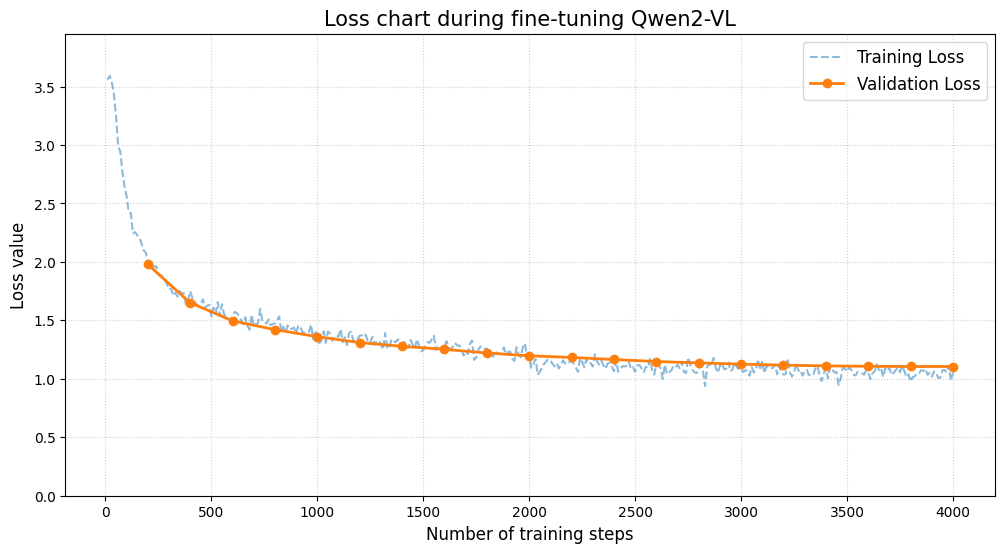

✅ Biểu đồ đã được lưu thành file 'learning_curve.png'. Bạn có thể tải về để đưa vào đồ án!


In [22]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Trích xuất dữ liệu từ lịch sử huấn luyện
history = trainer.state.log_history

# Tạo danh sách chứa Training Loss và Validation Loss
train_loss = []
eval_loss = []

for entry in history:
    if 'loss' in entry:
        train_loss.append({
            'Step': entry['step'],
            'Training Loss': entry['loss']
        })
    if 'eval_loss' in entry:
        eval_loss.append({
            'Step': entry['step'],
            'Validation Loss': entry['eval_loss']
        })

# 2. Chuyển sang DataFrame để dễ xử lý
df_train = pd.DataFrame(train_loss)
df_eval = pd.DataFrame(eval_loss)

# 3. Vẽ biểu đồ
plt.figure(figsize=(12, 6))

# Vẽ đường Training Loss
plt.plot(df_train['Step'], df_train['Training Loss'], 
         label='Training Loss', color='#1f77b4', alpha=0.5, linestyle='--')

# Vẽ đường Validation Loss (thường to và rõ hơn vì đây là mốc đánh giá quan trọng)
plt.plot(df_eval['Step'], df_eval['Validation Loss'], 
         label='Validation Loss', color='#ff7f0e', marker='o', linewidth=2)

# 4. Trang trí biểu đồ cho chuyên nghiệp
plt.title('Loss chart during fine-tuning Qwen2-VL', fontsize=15)
plt.xlabel('Number of training steps', fontsize=12)
plt.ylabel('Loss value', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

# Tự động điều chỉnh giới hạn trục Y để dễ nhìn nếu Loss giảm sâu
if not df_train.empty:
    plt.ylim(0, max(df_train['Training Loss'].max(), df_eval['Validation Loss'].max()) * 1.1)

# 5. Lưu biểu đồ ra file ảnh để đưa vào báo cáo
plt.savefig('learning_curve.png', dpi=300)
plt.show()

print("✅ Biểu đồ đã được lưu thành file 'learning_curve.png'. Bạn có thể tải về để đưa vào đồ án!")

In [19]:
# Trích xuất đường dẫn đến checkpoint tốt nhất từ trạng thái của trainer
best_checkpoint = trainer.state.best_model_checkpoint
best_loss = trainer.state.best_metric

print("="*50)
print(f"🏆 Checkpoint tốt nhất được chọn: {best_checkpoint}")
print(f"📉 Giá trị Validation Loss tại đó: {best_loss:.6f}")
print("="*50)

# Kiểm tra xem mô hình hiện tại trong RAM có phải là bản tốt nhất không
if trainer.args.load_best_model_at_end:
    print("✅ Trạng thái: Bản tốt nhất ĐÃ được nạp vào RAM. Lệnh save_model sẽ lưu bản này.")
else:
    print("⚠️ Trạng thái: Bản tốt nhất chưa được nạp. Lệnh save_model sẽ lưu bản cuối cùng.")

🏆 Checkpoint tốt nhất được chọn: HCMUS-Qwen2-VL-2B-Vietnamese-Image-Captioning-for-blind/checkpoint-4000
📉 Giá trị Validation Loss tại đó: 1.105124
✅ Trạng thái: Bản tốt nhất ĐÃ được nạp vào RAM. Lệnh save_model sẽ lưu bản này.


In [23]:
# Lưu mô hình LoRA
trainer.save_model(OUTPUT_DIR)

# Merge và Push lên HF Hub (Optionally)
# Lưu ý: Thông thường ta sẽ push Adapter (LoRA) lên vì nó nhẹ.
# Khi dùng chỉ cần load Base + Adapter.
trainer.push_to_hub(f"{OUTPUT_DIR}-Adapter")
processor.push_to_hub(f"{OUTPUT_DIR}-Adapter")

print(f"🎉 Hoàn thành! Model đã được tải lên Hugging Face tại: {OUTPUT_DIR}-Adapter")

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

🎉 Hoàn thành! Model đã được tải lên Hugging Face tại: HCMUS-Qwen2-VL-2B-Vietnamese-Image-Captioning-for-blind-Adapter


In [24]:
from peft import PeftModel

print("🔄 Đang trộn Adapter vào mô hình gốc để tạo bản Standalone...")

# 1. Load lại mô hình gốc (phải để torch_dtype giống lúc train)
base_model_to_merge = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    trust_remote_code=True
)

# 2. Nạp Adapter vừa train xong vào
model_to_merge = PeftModel.from_pretrained(base_model_to_merge, OUTPUT_DIR)

# 3. Trộn (Merge)
merged_model = model_to_merge.merge_and_unload()

# 4. Đẩy bản hoàn chỉnh (5GB) lên HF
merged_repo_id = f"{OUTPUT_DIR}-Final"
merged_model.push_to_hub(merged_repo_id)
processor.push_to_hub(merged_repo_id)

print(f"🚀 Tuyệt vời! Mô hình hoàn chỉnh đã sẵn sàng tại: {merged_repo_id}")

🔄 Đang trộn Adapter vào mô hình gốc để tạo bản Standalone...


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

README.md: 0.00B [00:00, ?B/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

🚀 Tuyệt vời! Mô hình hoàn chỉnh đã sẵn sàng tại: HCMUS-Qwen2-VL-2B-Vietnamese-Image-Captioning-for-blind-Final


In [25]:
# 1. Cấu hình thông số mới cho "đợt 2"
NEW_LEARNING_RATE = 2e-5  # Nhỏ hơn để học kĩ hơn
EXTRA_EPOCHS = 1          # Chạy thêm đúng 1 vòng nữa

# 2. Cập nhật lại SFTConfig
training_args_v2 = SFTConfig(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=1,
    gradient_checkpointing=True,
    
    learning_rate=NEW_LEARNING_RATE, # LR mới nhỏ hơn
    num_train_epochs=EXTRA_EPOCHS,   # Thêm 1 epoch
    
    bf16=True,
    logging_steps=10,
    eval_strategy="steps",
    save_strategy="steps",
    eval_steps=200,
    save_steps=200,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=2,
    remove_unused_columns=False,
    dataset_kwargs={"skip_prepare_dataset": True}
)

In [26]:
# 3. Khởi tạo lại Trainer với cấu hình mới
trainer = SFTTrainer(
    model=model,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    args=training_args_v2,
    data_collator=collate_fn,
)

In [27]:
# Bắt đầu huấn luyện Epoch thứ 3
trainer.train()

Step,Training Loss,Validation Loss
200,1.040733,1.110724
400,1.110844,1.107807
600,1.031594,1.107784
800,1.046913,1.101734
1000,0.997922,1.102333
1200,1.014720,1.100233
1400,0.936121,1.096856
1600,0.966617,1.096439
1800,0.976586,1.094789
2000,0.948767,1.094357


TrainOutput(global_step=2000, training_loss=1.0018168458938599, metrics={'train_runtime': 7410.4884, 'train_samples_per_second': 4.318, 'train_steps_per_second': 0.27, 'total_flos': 2.504511804087337e+17, 'train_loss': 1.0018168458938599})

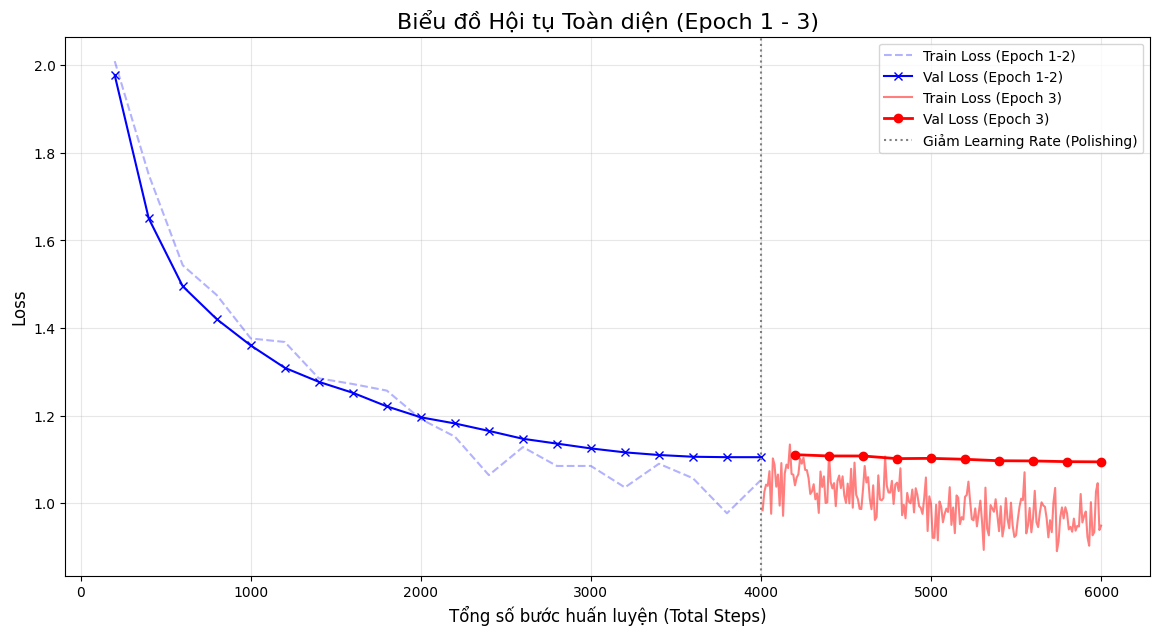

In [28]:
import matplotlib.pyplot as plt
import pandas as pd

# --- BƯỚC 1: NHẬP DỮ LIỆU CŨ (Từ Epoch 1 & 2 - Dựa trên bảng log bạn đã chạy) ---
# Tôi đã trích xuất các con số từ ảnh chụp màn hình trước đó của bạn
data_phase1 = [
    {'step': 200, 'loss': 2.009, 'eval_loss': 1.977},
    {'step': 400, 'loss': 1.750, 'eval_loss': 1.650},
    {'step': 600, 'loss': 1.543, 'eval_loss': 1.495},
    {'step': 800, 'loss': 1.475, 'eval_loss': 1.420},
    {'step': 1000, 'loss': 1.376, 'eval_loss': 1.360},
    {'step': 1200, 'loss': 1.368, 'eval_loss': 1.309},
    {'step': 1400, 'loss': 1.285, 'eval_loss': 1.277},
    {'step': 1600, 'loss': 1.272, 'eval_loss': 1.252},
    {'step': 1800, 'loss': 1.257, 'eval_loss': 1.221},
    {'step': 2000, 'loss': 1.192, 'eval_loss': 1.196},
    {'step': 2200, 'loss': 1.152, 'eval_loss': 1.182},
    {'step': 2400, 'loss': 1.064, 'eval_loss': 1.165},
    {'step': 2600, 'loss': 1.128, 'eval_loss': 1.147},
    {'step': 2800, 'loss': 1.085, 'eval_loss': 1.136},
    {'step': 3000, 'loss': 1.085, 'eval_loss': 1.125},
    {'step': 3200, 'loss': 1.036, 'eval_loss': 1.116},
    {'step': 3400, 'loss': 1.090, 'eval_loss': 1.110},
    {'step': 3600, 'loss': 1.057, 'eval_loss': 1.106},
    {'step': 3800, 'loss': 0.977, 'eval_loss': 1.105},
    {'step': 4000, 'loss': 1.053, 'eval_loss': 1.105},
]

# --- BƯỚC 2: LẤY DỮ LIỆU MỚI (Từ Epoch 3 đang chạy) ---
history_v2 = trainer.state.log_history
data_phase2 = []

# Mốc offset là 4000 (vì Epoch 3 bắt đầu sau khi Epoch 2 kết thúc tại bước 4000)
OFFSET = 4000 

for entry in history_v2:
    step = entry.get('step', 0) + OFFSET
    if 'loss' in entry:
        data_phase2.append({'step': step, 'loss': entry['loss'], 'type': 'train'})
    if 'eval_loss' in entry:
        data_phase2.append({'step': step, 'loss': entry['eval_loss'], 'type': 'val'})

# --- BƯỚC 3: KẾT HỢP VÀ VẼ ---
plt.figure(figsize=(14, 7))

# Vẽ Phase 1 (Epoch 1 & 2)
steps_p1 = [d['step'] for d in data_phase1]
train_p1 = [d['loss'] for d in data_phase1]
val_p1 = [d['eval_loss'] for d in data_phase1]

plt.plot(steps_p1, train_p1, label='Train Loss (Epoch 1-2)', color='blue', alpha=0.3, linestyle='--')
plt.plot(steps_p1, val_p1, label='Val Loss (Epoch 1-2)', color='blue', marker='x')

# Vẽ Phase 2 (Epoch 3 - Polishing)
# Chuyển phase 2 sang DataFrame để dễ lọc
df_p2 = pd.DataFrame(data_phase2)
if not df_p2.empty:
    df_p2_train = df_p2[df_p2['type'] == 'train']
    df_p2_val = df_p2[df_p2['type'] == 'val']
    
    plt.plot(df_p2_train['step'], df_p2_train['loss'], label='Train Loss (Epoch 3)', color='red', alpha=0.5)
    plt.plot(df_p2_val['step'], df_p2_val['loss'], label='Val Loss (Epoch 3)', color='red', marker='o', linewidth=2)

# Thêm đường kẻ đánh dấu mốc thay đổi Learning Rate
plt.axvline(x=4000, color='gray', linestyle=':', label='Giảm Learning Rate (Polishing)')

# Trang trí
plt.title('Biểu đồ Hội tụ Toàn diện (Epoch 1 - 3)', fontsize=16)
plt.xlabel('Tổng số bước huấn luyện (Total Steps)', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# Lưu và hiển thị
plt.savefig('full_training_curve.png', dpi=300)
plt.show()

In [29]:
# Trích xuất đường dẫn đến checkpoint tốt nhất từ trạng thái của trainer
best_checkpoint = trainer.state.best_model_checkpoint
best_loss = trainer.state.best_metric

print("="*50)
print(f"🏆 Checkpoint tốt nhất được chọn: {best_checkpoint}")
print(f"📉 Giá trị Validation Loss tại đó: {best_loss:.6f}")
print("="*50)

# Kiểm tra xem mô hình hiện tại trong RAM có phải là bản tốt nhất không
if trainer.args.load_best_model_at_end:
    print("✅ Trạng thái: Bản tốt nhất ĐÃ được nạp vào RAM. Lệnh save_model sẽ lưu bản này.")
else:
    print("⚠️ Trạng thái: Bản tốt nhất chưa được nạp. Lệnh save_model sẽ lưu bản cuối cùng.")

🏆 Checkpoint tốt nhất được chọn: HCMUS-Qwen2-VL-2B-Vietnamese-Image-Captioning-for-blind/checkpoint-2000
📉 Giá trị Validation Loss tại đó: 1.094357
✅ Trạng thái: Bản tốt nhất ĐÃ được nạp vào RAM. Lệnh save_model sẽ lưu bản này.


In [30]:
print("💾 Đang lưu mô hình đã 'đánh bóng' vào ổ cứng local...")
trainer.save_model(f"{OUTPUT_DIR}-Final-LoRA")
processor.save_pretrained(f"{OUTPUT_DIR}-Final-LoRA")
print("✅ Đã lưu bản LoRA cuối cùng.")

💾 Đang lưu mô hình đã 'đánh bóng' vào ổ cứng local...
✅ Đã lưu bản LoRA cuối cùng.


In [31]:
import torch
from peft import PeftModel
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor

# 1. Giải phóng bộ não cũ để lấy chỗ trống
del model
del trainer
torch.cuda.empty_cache()

print("🔄 Đang tiến hành trộn (Merge) trọng số để tạo bản Standalone...")

# 2. Load lại mô hình gốc (Bản sạch)
base_model = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16, # Dùng bf16 cho nhẹ và chính xác trên A100
    device_map="auto",
    trust_remote_code=True
)

# 3. Nạp Adapter (những gì mới học ở Epoch 3) đè lên
model_to_merge = PeftModel.from_pretrained(base_model, f"{OUTPUT_DIR}-Final-LoRA")

# 4. Trộn vĩnh viễn (Merge)
merged_model = model_to_merge.merge_and_unload()

print("✅ Đã trộn xong! Mô hình bây giờ là một khối thống nhất.")

🔄 Đang tiến hành trộn (Merge) trọng số để tạo bản Standalone...


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

✅ Đã trộn xong! Mô hình bây giờ là một khối thống nhất.


In [32]:
# Tên thư mục trên Hugging Face của bạn
HF_REPO_NAME = "HCMUS-Qwen2-VL-2B-Instruct-Vietnamese-Captioning-for-blind"

print(f"🚀 Đang đẩy mô hình hoàn chỉnh lên Hugging Face: {HF_REPO_NAME}...")

# 1. Push mô hình (Khoảng 4.5 - 5 GB)
merged_model.push_to_hub(HF_REPO_NAME)

# 2. Push bộ xử lý (Cực kỳ quan trọng để App đọc được ảnh)
processor.push_to_hub(HF_REPO_NAME)

print(f"🎉 TẤT CẢ ĐÃ XONG! Mô hình của bạn đã sẵn sàng tại: https://huggingface.co/{HF_REPO_NAME}")

🚀 Đang đẩy mô hình hoàn chỉnh lên Hugging Face: HCMUS-Qwen2-VL-2B-Instruct-Vietnamese-Captioning-for-blind...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

README.md: 0.00B [00:00, ?B/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

🎉 TẤT CẢ ĐÃ XONG! Mô hình của bạn đã sẵn sàng tại: https://huggingface.co/HCMUS-Qwen2-VL-2B-Instruct-Vietnamese-Captioning-for-blind


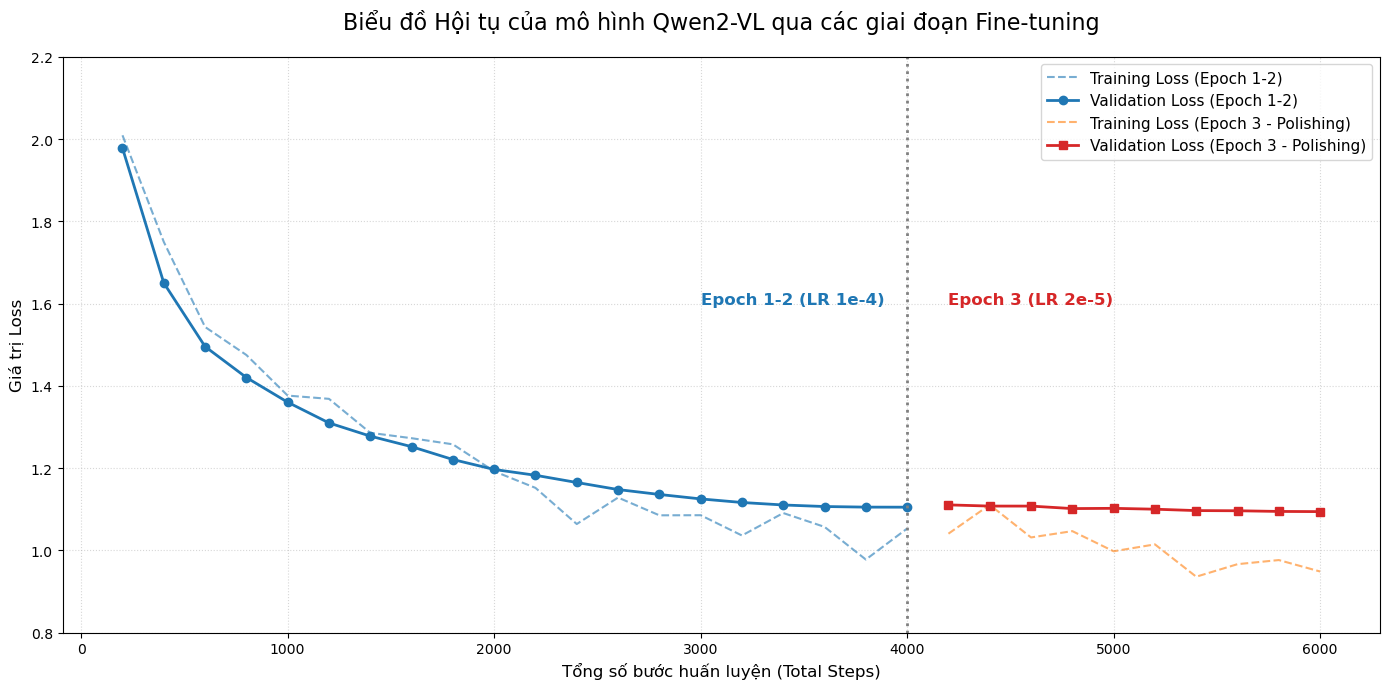

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

# --- 1. DỮ LIỆU GIAI ĐOẠN 1 (Epoch 1-2) ---
steps_p1 = [200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000, 2200, 2400, 2600, 2800, 3000, 3200, 3400, 3600, 3800, 4000]
train_p1 = [2.009192, 1.750013, 1.543156, 1.475081, 1.376396, 1.368502, 1.285894, 1.272822, 1.257941, 1.192409, 1.152061, 1.064168, 1.128513, 1.085361, 1.085622, 1.036337, 1.090878, 1.057231, 0.977839, 1.053238]
val_p1   = [1.977924, 1.650253, 1.495559, 1.420342, 1.360276, 1.309942, 1.277856, 1.252232, 1.221002, 1.196821, 1.182709, 1.165161, 1.147961, 1.136046, 1.125237, 1.116551, 1.110497, 1.106740, 1.105280, 1.105124]

# --- 2. DỮ LIỆU GIAI ĐOẠN 2 (Epoch 3 - Polishing) ---
# Chúng ta cộng thêm 4000 vào step để biểu đồ liên tục
OFFSET = 4000
steps_p2 = [200+OFFSET, 400+OFFSET, 600+OFFSET, 800+OFFSET, 1000+OFFSET, 1200+OFFSET, 1400+OFFSET, 1600+OFFSET, 1800+OFFSET, 2000+OFFSET]
train_p2 = [1.040733, 1.110844, 1.031594, 1.046913, 0.997922, 1.014720, 0.936121, 0.966617, 0.976586, 0.948767]
val_p2   = [1.110724, 1.107807, 1.107784, 1.101734, 1.102333, 1.100233, 1.096856, 1.096439, 1.094789, 1.094357]

# --- 3. VẼ BIỂU ĐỒ ---
plt.figure(figsize=(14, 7))

# Vẽ Giai đoạn 1 (Màu xanh)
plt.plot(steps_p1, train_p1, label='Training Loss (Epoch 1-2)', color='#1f77b4', linestyle='--', alpha=0.6)
plt.plot(steps_p1, val_p1, label='Validation Loss (Epoch 1-2)', color='#1f77b4', marker='o', linewidth=2)

# Vẽ Giai đoạn 2 (Màu cam/đỏ)
plt.plot(steps_p2, train_p2, label='Training Loss (Epoch 3 - Polishing)', color='#ff7f0e', linestyle='--', alpha=0.6)
plt.plot(steps_p2, val_p2, label='Validation Loss (Epoch 3 - Polishing)', color='#d62728', marker='s', linewidth=2)

# Thêm đường phân cách giữa 2 giai đoạn
plt.axvline(x=4000, color='gray', linestyle=':', linewidth=2)
plt.text(3000, 1.6, 'Epoch 1-2 (LR 1e-4)', fontsize=12, fontweight='bold', color='#1f77b4')
plt.text(4200, 1.6, 'Epoch 3 (LR 2e-5)', fontsize=12, fontweight='bold', color='#d62728')

# Trang trí
plt.title('Biểu đồ Hội tụ của mô hình Qwen2-VL qua các giai đoạn Fine-tuning', fontsize=16, pad=20)
plt.xlabel('Tổng số bước huấn luyện (Total Steps)', fontsize=12)
plt.ylabel('Giá trị Loss', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(fontsize=11)

# Tự động chỉnh mốc trục Y để dễ nhìn
plt.ylim(0.8, 2.2)

# Lưu ảnh
plt.tight_layout()
plt.savefig('combined_loss_chart.png', dpi=300)
plt.show()

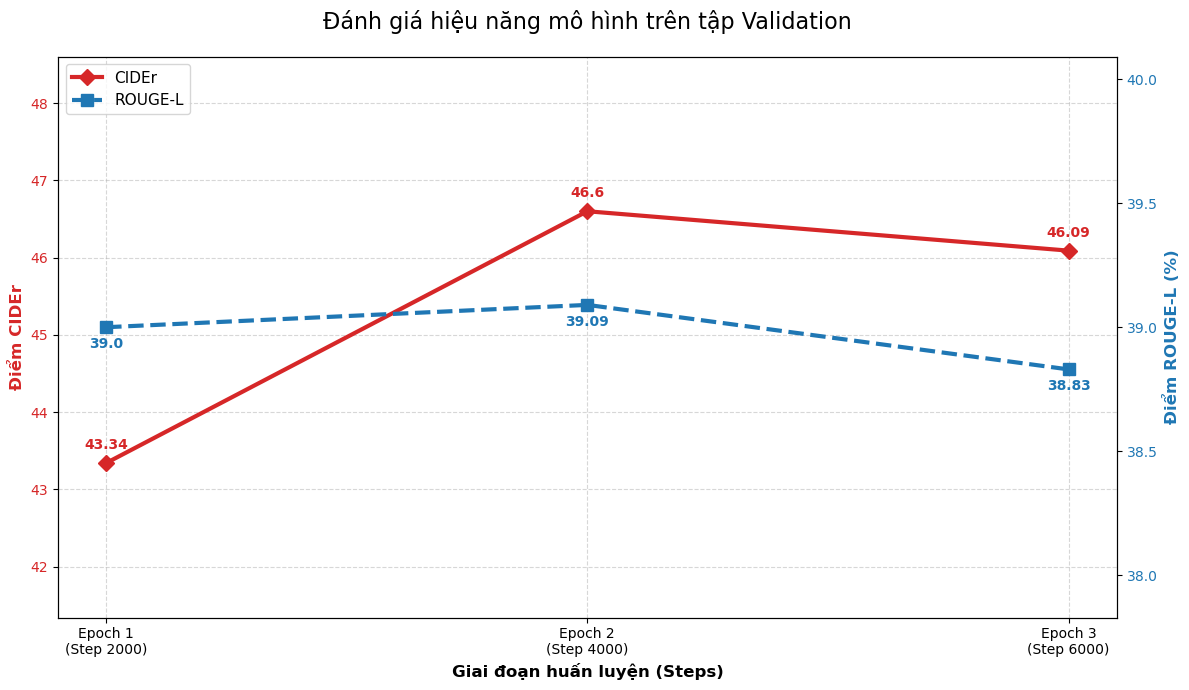

In [11]:
import matplotlib.pyplot as plt

# 1. Dữ liệu thực tế từ bảng kết quả tập Val của bạn
milestones = ['Epoch 1\n(Step 2000)', 'Epoch 2\n(Step 4000)', 'Epoch 3\n(Step 6000)']
steps = [2000, 4000, 6000]
cider_scores = [43.34, 46.60, 46.09]
rouge_scores = [39.00, 39.09, 38.83]

fig, ax1 = plt.subplots(figsize=(12, 7))

# --- VẼ ĐƯỜNG CIDER (Trục bên trái) ---
color_cider = '#d62728' # Màu đỏ đô
ax1.set_xlabel('Giai đoạn huấn luyện (Steps)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Điểm CIDEr', color=color_cider, fontsize=12, fontweight='bold')
line1 = ax1.plot(steps, cider_scores, marker='D', markersize=8, color=color_cider, 
                 linewidth=3, label='CIDEr')
ax1.tick_params(axis='y', labelcolor=color_cider)
ax1.grid(True, linestyle='--', alpha=0.5)

# Thêm số liệu cụ thể cho CIDEr
for i, txt in enumerate(cider_scores):
    ax1.annotate(f'{txt}', (steps[i], cider_scores[i]), textcoords="offset points", 
                 xytext=(0,10), ha='center', color=color_cider, fontweight='bold')

# --- VẼ ĐƯỜNG ROUGE-L (Trục bên phải) ---
ax2 = ax1.twinx() 
color_rouge = '#1f77b4' # Màu xanh dương
ax2.set_ylabel('Điểm ROUGE-L (%)', color=color_rouge, fontsize=12, fontweight='bold')
line2 = ax2.plot(steps, rouge_scores, marker='s', markersize=8, color=color_rouge, 
                 linewidth=3, linestyle='--', label='ROUGE-L')
ax2.tick_params(axis='y', labelcolor=color_rouge)

# Thêm số liệu cụ thể cho ROUGE-L
for i, txt in enumerate(rouge_scores):
    ax2.annotate(f'{txt}', (steps[i], rouge_scores[i]), textcoords="offset points", 
                 xytext=(0,-15), ha='center', color=color_rouge, fontweight='bold')

# --- ĐIỀU CHỈNH KHOẢNG TRỰC Y ĐỂ DỄ NHÌN BIẾN THIÊN ---
ax1.set_ylim(min(cider_scores) - 2, max(cider_scores) + 2)
ax2.set_ylim(min(rouge_scores) - 1, max(rouge_scores) + 1)

# --- CHÚ THÍCH VÀ TIÊU ĐỀ ---
plt.title('Đánh giá hiệu năng mô hình trên tập Validation', fontsize=16, pad=20)
plt.xticks(steps, milestones)

# Gom chú thích từ 2 trục vào 1 hộp
lns = line1 + line2
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc='upper left', fontsize=11)

plt.tight_layout()
plt.savefig('val_metrics_comparison.png', dpi=300)
plt.show()